# Importing Libraries and Data

In [22]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans # Here is where you import the k-means algorithm from scikit-learn.
import pylab as pl # PyLab is a convenience module that bulk imports matplotlib.
from sklearn.preprocessing import StandardScaler

In [6]:
# Enable inline plotting for Jupyter Notebook
%matplotlib inline

In [4]:
# importing dataframe
df = pd.read_csv(r'C:\users\Maham Rauf\Documents\US gun violence data analysis\Data\Prepared data\gun-violence-cleaned.csv', index_col = False)

In [8]:
# Display first few rows
df.head()

,incident_id,date,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,...,longitude,n_guns_involved,notes,participant_age_group,participant_gender,participant_status,participant_type,sources,state_house_district,state_senate_district
0,461105,1/1/2013,Pennsylvania,Mckeesport,1506 Versailles Avenue and Coursin Street,0,4,http://www.gunviolencearchive.org/incident/461105,http://www.post-gazette.com/local/south/2013/0...,False,...,-79.8559,1,Julian Sims under investigation: Four Shot and...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,-1,-1
1,460726,1/1/2013,California,Hawthorne,13500 block of Cerise Avenue,1,3,http://www.gunviolencearchive.org/incident/460726,http://www.dailybulletin.com/article/zz/201301...,False,...,-118.3330,1,Four Shot; One Killed; Unidentified shooter in...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62,35
2,478855,1/1/2013,Ohio,Lorain,1776 East 28th Street,1,3,http://www.gunviolencearchive.org/incident/478855,http://chronicle.northcoastnow.com/2013/02/14/...,False,...,-82.1377,2,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56,13
3,478925,1/5/2013,Colorado,Aurora,16000 block of East Ithaca Place,4,0,http://www.gunviolencearchive.org/incident/478925,http://www.dailydemocrat.com/20130106/aurora-s...,False,...,-104.8020,1,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40,28
4,478959,1/7/2013,North Carolina,Greensboro,307 Mourning Dove Terrace,2,2,http://www.gunviolencearchive.org/incident/478959,http://www.journalnow.com/news/local/article_d...,False,...,-79.9569,2,Two firearms recovered. (Attempted) murder sui...,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62,27


In [10]:
# Check for missing values
print(df.isnull().sum())

incident_id                    0
date                           0
state                          0
city_or_county                 0
address                        0
n_killed                       0
n_injured                      0
incident_url                   0
source_url                     0
incident_url_fields_missing    0
congressional_district         0
gun_stolen                     0
gun_type                       0
incident_characteristics       0
latitude                       0
longitude                      0
n_guns_involved                0
notes                          0
participant_age_group          0
participant_gender             0
participant_status             0
participant_type               0
sources                        0
state_house_district           0
state_senate_district          0
dtype: int64


In [12]:
# Drop irrelevant or missing data
df = df.dropna()

In [14]:
# Display basic statistics
df.describe()

,incident_id,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
count,2.396770e+05,239677.000000,239677.000000,239677.000000,239677.000000,239677.000000,239677.000000,239677.000000,239677.000000
mean,5.593343e+05,0.252290,0.494007,7.552698,37.580449,-89.236244,1.217902,46.315808,17.579618
std,2.931287e+05,0.521779,0.729952,8.495690,5.048567,14.131003,3.583024,43.750294,15.112348
min,9.211400e+04,0.000000,0.000000,-1.000000,19.111400,-171.429000,1.000000,-1.000000,-1.000000
25%,3.085450e+05,0.000000,0.000000,2.000000,33.985200,-93.600900,1.000000,9.000000,5.000000
50%,5.435870e+05,0.000000,0.000000,5.000000,38.570600,-86.249600,1.000000,35.000000,15.000000
75%,8.172280e+05,0.000000,1.000000,10.000000,41.285100,-80.136700,1.000000,77.000000,29.000000
max,1.083472e+06,50.000000,53.000000,53.000000,71.336800,97.433100,400.000000,901.000000,94.000000


In [16]:
# Remove Categorical Columns (K-Means Requires Numeric Data)
# Drop non-numeric columns (e.g., 'state', 'city', 'gun_type', etc.)
df_numeric = df.select_dtypes(include=[np.number])

In [18]:
# Display first few rows of numeric data
df_numeric.head()

,incident_id,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
0,461105,0,4,14,40.3467,-79.8559,1,-1,-1
1,460726,1,3,43,33.9090,-118.3330,1,62,35
2,478855,1,3,9,41.4455,-82.1377,2,56,13
3,478925,4,0,6,39.6518,-104.8020,1,40,28
4,478959,2,2,6,36.1140,-79.9569,2,62,27


In [24]:
# Standardize the Data (Scaling is Important for K-Means)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

In [26]:
# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

In [28]:
# Check scaled data
df_scaled.describe()

,incident_id,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
count,2.396770e+05,2.396770e+05,2.396770e+05,2.396770e+05,2.396770e+05,2.396770e+05,2.396770e+05,2.396770e+05,2.396770e+05
mean,-1.271214e-16,-1.701672e-17,-8.721808e-17,1.612734e-17,1.092034e-15,4.405076e-16,1.316276e-17,-3.984402e-17,-1.071994e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-1.593912e+00,-4.835191e-01,-6.767669e-01,-1.006712e+00,-3.658283e+00,-5.816497e+00,-6.081512e-02,-1.081499e+00,-1.229435e+00
25%,-8.555624e-01,-4.835191e-01,-6.767669e-01,-6.535914e-01,-7.121340e-01,-3.088716e-01,-6.081512e-02,-8.529288e-01,-8.324083e-01
50%,-5.372173e-02,-4.835191e-01,-6.767669e-01,-3.004704e-01,1.961256e-01,2.113544e-01,-6.081512e-02,-2.586458e-01,-1.706964e-01
75%,8.797986e-01,-4.835191e-01,6.931885e-01,2.880646e-01,7.338041e-01,6.439432e-01,-6.081512e-02,7.013497e-01,7.557003e-01
max,1.788084e+00,9.534271e+01,7.193087e+01,5.349465e+00,6.686337e+00,1.320994e+01,1.112979e+02,1.953555e+01,5.056828e+00


# Elbow method

In [31]:
# Use the Elbow Method to Determine Optimal K (Clusters)
wcss = []  # Within-cluster sum of squares


In [33]:
# Try different values of k (number of clusters)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # Append WCSS value

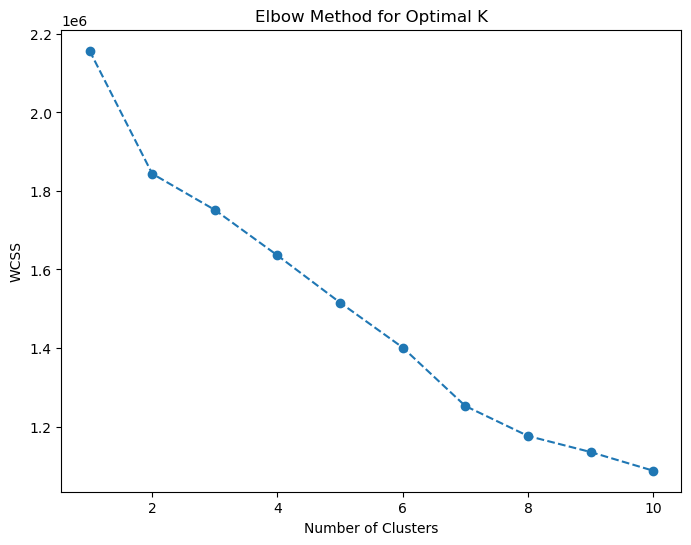

In [35]:
# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

### **📌 Choosing the Optimal Number of Clusters**
- The **"elbow point"** is where the WCSS curve starts to bend.
- Based on the plot, the optimal number of clusters is around **K = 4** 
- Choosing too many clusters may result in **overfitting**, while too few clusters may **miss important patterns**.

# k-means clustering

In [39]:
optimal_k = 4

In [41]:
# Train K-Means Model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_scaled['Cluster'] = kmeans.fit_predict(df_scaled)

In [43]:
# Add cluster labels to original dataset
df['Cluster'] = df_scaled['Cluster']

In [45]:
# Display first few rows with clusters
df.head()

,incident_id,date,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,...,n_guns_involved,notes,participant_age_group,participant_gender,participant_status,participant_type,sources,state_house_district,state_senate_district,Cluster
0,461105,1/1/2013,Pennsylvania,Mckeesport,1506 Versailles Avenue and Coursin Street,0,4,http://www.gunviolencearchive.org/incident/461105,http://www.post-gazette.com/local/south/2013/0...,False,...,1,Julian Sims under investigation: Four Shot and...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||3::Male||4::Female,0::Arrested||1::Injured||2::Injured||3::Injure...,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://pittsburgh.cbslocal.com/2013/01/01/4-pe...,-1,-1,0
1,460726,1/1/2013,California,Hawthorne,13500 block of Cerise Avenue,1,3,http://www.gunviolencearchive.org/incident/460726,http://www.dailybulletin.com/article/zz/201301...,False,...,1,Four Shot; One Killed; Unidentified shooter in...,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male,0::Killed||1::Injured||2::Injured||3::Injured,0::Victim||1::Victim||2::Victim||3::Victim||4:...,http://losangeles.cbslocal.com/2013/01/01/man-...,62,35,0
2,478855,1/1/2013,Ohio,Lorain,1776 East 28th Street,1,3,http://www.gunviolencearchive.org/incident/478855,http://chronicle.northcoastnow.com/2013/02/14/...,False,...,2,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Male||1::Male||2::Male||3::Male||4::Male,"0::Injured, Unharmed, Arrested||1::Unharmed, A...",0::Subject-Suspect||1::Subject-Suspect||2::Vic...,http://www.morningjournal.com/general-news/201...,56,13,0
3,478925,1/5/2013,Colorado,Aurora,16000 block of East Ithaca Place,4,0,http://www.gunviolencearchive.org/incident/478925,http://www.dailydemocrat.com/20130106/aurora-s...,False,...,1,Unknown,0::Adult 18+||1::Adult 18+||2::Adult 18+||3::A...,0::Female||1::Male||2::Male||3::Male,0::Killed||1::Killed||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://denver.cbslocal.com/2013/01/06/officer-...,40,28,2
4,478959,1/7/2013,North Carolina,Greensboro,307 Mourning Dove Terrace,2,2,http://www.gunviolencearchive.org/incident/478959,http://www.journalnow.com/news/local/article_d...,False,...,2,Two firearms recovered. (Attempted) murder sui...,0::Adult 18+||1::Adult 18+||2::Teen 12-17||3::...,0::Female||1::Male||2::Male||3::Female,0::Injured||1::Injured||2::Killed||3::Killed,0::Victim||1::Victim||2::Victim||3::Subject-Su...,http://myfox8.com/2013/01/08/update-mother-sho...,62,27,0


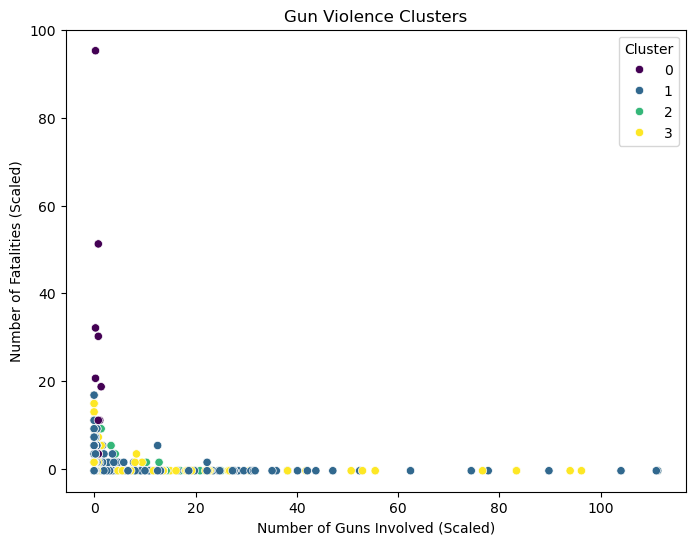

In [49]:
# Visualize Clusters Using Scatter Plots
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_scaled['n_guns_involved'], y=df_scaled['n_killed'], hue=df_scaled['Cluster'], palette='viridis')
plt.xlabel("Number of Guns Involved (Scaled)")
plt.ylabel("Number of Fatalities (Scaled)")
plt.title("Gun Violence Clusters")
plt.legend(title="Cluster")
plt.show()

### **Interpretation of Clustering Results**
- The scatter plot shows **distinct clusters** of gun violence incidents.
- Clusters may represent:
  1. **Low-severity incidents** (fewer guns, fewer casualties).
  2. **High-severity incidents** (multiple guns, high fatalities).
  3. **Anomalies or outliers** (mass shootings or extreme cases).
- If clusters **do not make sense**, feature selection and clustering parameters may need refinement.

In [56]:
# Select only numeric columns before calculating statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

In [58]:
# Calculate mean values for each cluster
cluster_summary = df.groupby('Cluster')[numeric_cols].mean()


In [62]:
# Display the cluster summary in Jupyter Notebook
print(cluster_summary)


           incident_id  n_killed  n_injured  congressional_district  \
Cluster                                                               
0        559819.236049  0.171311   2.425725                6.445295   
1        837117.186759  0.261759   0.377680                4.229357   
2        310676.267370  0.227867   0.373077                4.883328   
3        539683.312195  0.287213   0.368408               14.683023   

          latitude  longitude  n_guns_involved  state_house_district  \
Cluster                                                                
0        37.678106 -88.345211         1.063107             40.706587   
1        38.451421 -89.270909         1.345408             25.194394   
2        39.260210 -89.505405         1.105595             28.922409   
3        34.593747 -89.063540         1.238789             91.842729   

         state_senate_district  Cluster  
Cluster                                  
0                    15.652060      0.0  
1             

In [64]:
# If the output is too long, show only the first few rows
cluster_summary.head()


,incident_id,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district,Cluster
Cluster,,,,,,,,,,
0,559819.236049,0.171311,2.425725,6.445295,37.678106,-88.345211,1.063107,40.706587,15.652060,0.0
1,837117.186759,0.261759,0.377680,4.229357,38.451421,-89.270909,1.345408,25.194394,10.784326,1.0
2,310676.267370,0.227867,0.373077,4.883328,39.260210,-89.505405,1.105595,28.922409,12.780739,2.0
3,539683.312195,0.287213,0.368408,14.683023,34.593747,-89.063540,1.238789,91.842729,31.310728,3.0


In [66]:
# Save the summary as a CSV file (optional)
cluster_summary.to_csv("cluster_summary.csv")

### ** Key Insights from Clustering Analysis**
- Different clusters **group similar incidents**, revealing potential trends.
- **High-risk categories** can be identified (e.g., incidents with multiple firearms are deadlier).
- Law enforcement and policymakers can use these insights to **focus on high-risk areas**.
- Further steps could involve **geospatial mapping** to correlate clusters with location.
